# Phase 4 — WER from AssemblyAI Transcriptions

We use Vounded app, which use AssemblyAI as third party transcriptor to generate the transcriptions of the 60 seconds audio segments, stored in transcriptions.md.

In this notebook we compute the WER for all the SNR levels, using as reference the clean conversation.

In [7]:
import re, json, pathlib
import numpy as np
import matplotlib.pyplot as plt
from jiwer import wer, Compose, ToLowerCase, RemovePunctuation, RemoveMultipleSpaces, Strip, ReduceToListOfListOfWords

DATA_DIR = pathlib.Path.cwd().parent / 'data' / 'synth'
TR_FILE  = DATA_DIR / 'transcription_segments_60s' / 'transcriptions.md'
SNRS     = [-5, 0, 5, 10, 15]

## 1. Parse transcriptions.md

In [2]:
raw = TR_FILE.read_text()
sections = re.findall(r'^## (\S+)\s*\n+(.*?)(?=^## |\Z)', raw, flags=re.M | re.S)
transcripts = {key: text.strip() for key, text in sections}
print(f'Parsed {len(transcripts)} sections:')
for k, v in transcripts.items():
    print(f'  {k:18s} {len(v.split()):4d} words')

Parsed 16 sections:
  clean               181 words
  kalman_-5dB          71 words
  kalman_+0dB         140 words
  kalman_+5dB         170 words
  kalman_+10dB        173 words
  kalman_+15dB        178 words
  mix_-5dB            101 words
  mix_+0dB            163 words
  mix_+5dB            174 words
  mix_+10dB           179 words
  mix_+15dB           179 words
  pf_-5dB              51 words
  pf_+0dB             128 words
  pf_+5dB             168 words
  pf_+10dB            170 words
  pf_+15dB            177 words


## 2. WER configuration

Normalization of the transcriptions.

In [3]:
transform = Compose([
    ToLowerCase(),
    RemovePunctuation(),
    RemoveMultipleSpaces(),
    Strip(),
    ReduceToListOfListOfWords(),
])

def compute_wer(ref: str, hyp: str) -> float:
    return wer(ref, hyp, reference_transform=transform, hypothesis_transform=transform)

reference = transcripts['clean']

## 3. WER for every condition

In [4]:
def snr_key(snr): return f'+{snr}dB' if snr >= 0 else f'{snr}dB'

rows = []
for snr in SNRS:
    sk = snr_key(snr)
    w_noisy = compute_wer(reference, transcripts[f'mix_{sk}'])
    w_kf    = compute_wer(reference, transcripts[f'kalman_{sk}'])
    w_pf    = compute_wer(reference, transcripts[f'pf_{sk}'])
    rows.append({'snr': snr, 'noisy': w_noisy, 'kf': w_kf, 'pf': w_pf})

print(f"{'SNR':>5}  {'Noisy':>7}  {'KF':>7}  {'PF':>7}  best")
for r in rows:
    best = min(r['noisy'], r['kf'], r['pf'])
    label = 'Noisy' if best == r['noisy'] else ('KF' if best == r['kf'] else 'PF')
    print(f"  {r['snr']:+3d}  {r['noisy']:7.3f}  {r['kf']:7.3f}  {r['pf']:7.3f}  {label}")

  SNR    Noisy       KF       PF  best
   -5    0.497    0.669    0.768  Noisy
   +0    0.199    0.381    0.398  Noisy
   +5    0.144    0.166    0.166  Noisy
  +10    0.083    0.110    0.122  Noisy
  +15    0.028    0.033    0.033  Noisy


## 4. Plot WER vs SNR

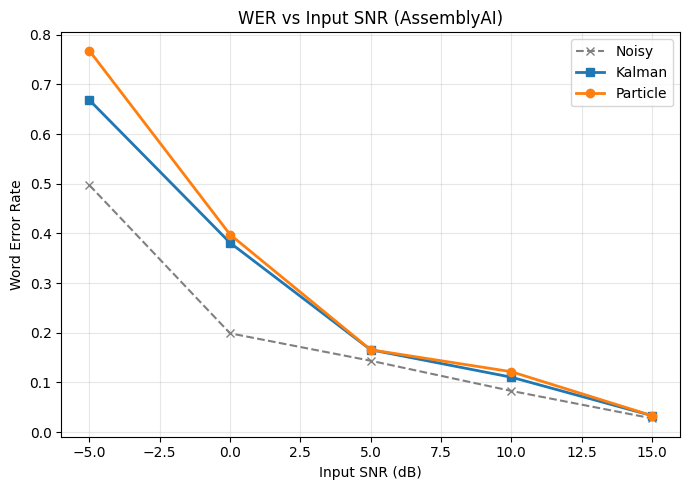

In [5]:
snrs = [r['snr'] for r in rows]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(snrs, [r['noisy'] for r in rows], 'x--', label='Noisy', color='gray')
ax.plot(snrs, [r['kf']    for r in rows], 's-',  label='Kalman',  linewidth=2)
ax.plot(snrs, [r['pf']    for r in rows], 'o-',  label='Particle', linewidth=2)
ax.set_xlabel('Input SNR (dB)')
ax.set_ylabel('Word Error Rate')
ax.set_title('WER vs Input SNR (AssemblyAI)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'wer_vs_snr_assemblyai.png'), dpi=150)
plt.show()

## 5. Save results

In [6]:
out = [{'snr_in': r['snr'], 'wer_noisy': r['noisy'], 'wer_kf': r['kf'], 'wer_pf': r['pf']} for r in rows]
with open(DATA_DIR / 'wer_results_assemblyai.json', 'w') as f:
    json.dump(out, f, indent=2)
print('Saved wer_results_assemblyai.json')

Saved wer_results_assemblyai.json


## 6. Headline plot: MI vs WER

Pool all (MI, WER) points across SNR levels and conditions (Noisy / KF / PF)
and fit a line.

In [ ]:
from scipy.stats import pearsonr

LOG2E = np.log2(np.e)
with open(DATA_DIR / 'info_theory_results.json') as f:
    it_data = json.load(f)
it_by_snr = {d['snr_in']: d for d in it_data}

mi_all, wer_all, labels = [], [], []
for r in rows:
    it = it_by_snr[r['snr']]
    mi_all += [it['mi_noisy'], it['mi_kf'], it['mi_pf']]
    wer_all += [r['noisy'], r['kf'], r['pf']]
    labels  += ['Noisy', 'KF', 'PF']

mi_arr  = np.array(mi_all) * LOG2E
wer_arr = np.array(wer_all)

r_val, p_val = pearsonr(mi_arr, wer_arr)
coeffs = np.polyfit(mi_arr, wer_arr, 1)
mi_fit = np.linspace(mi_arr.min(), mi_arr.max(), 100)
wer_fit = np.polyval(coeffs, mi_fit)
print(f'Pearson r = {r_val:.4f}, p = {p_val:.2e}')

fig, ax = plt.subplots(figsize=(7, 5))
colors  = {'Noisy': 'gray', 'KF': 'tab:blue', 'PF': 'tab:orange'}
markers = {'Noisy': 'x',    'KF': 's',        'PF': 'o'}
for lbl in ['Noisy', 'KF', 'PF']:
    mask = [l == lbl for l in labels]
    ax.scatter(mi_arr[mask], wer_arr[mask], c=colors[lbl], marker=markers[lbl],
               s=80, label=lbl, zorder=3)
ax.plot(mi_fit, wer_fit, 'r--', alpha=0.7, label=f'Linear fit (r={r_val:.2f})')
ax.set_xlabel('Mutual Information I(x; x̂) [bits]')
ax.set_ylabel('Word Error Rate (AssemblyAI)')
ax.set_title('MI vs WER: Higher information ↔ Lower transcription error')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'mi_vs_wer_assemblyai.png'), dpi=150)
plt.show()